# Figure 2 (and Figures S3, S4)

This notebook reproduces every panel of Figure 2 and the supplementary heatmaps:

| Output | Content |
| --- | --- |
| **Figure 2a** | SGB richness (kSGBs / uSGBs) in Westernized vs non-Westernized samples, from read-subsampled profiles, with Mann-Whitney p-values |
| **Figure 2b** | Jaccard PCoA of adult and ancient samples, coloured by lifestyle |
| **Figure 2c** | The same ordination coloured by HDI 2019 |
| **Figure 2d** | Prevalence heatmap of the 15 most Westernized- and 15 most non-Westernized-enriched SGBs |
| **Figure S3** | Prevalence heatmap of the *Prevotella* / *Bacteroides* / *Phocaeicola* SGBs |
| **Figure S4a/b** | Prevalence heatmaps of the most discriminative genera and families |
| **Figure S2** | Sensitivity of the lifestyle effect to injected per-study bias |
| **Figure S1a-h** | Diversity, MAG counts, read depth and beta dispersion by lifestyle |

Panels d, S3 and S4 all share the differential-prevalence analysis in section 4. Figure S2, in section 8, re-fits that same model under injected bias. Figure S1, in section 9, is the confounder check behind Figure 2: diversity, assembly yield and sequencing depth, compared between lifestyles.

## 0. Setup

`SGB_DB` is only used to build the display labels for unnamed SGBs. `SUBSAMPLED_DIR` holds the per-sample subsampled MetaPhlAn profiles used by panel a. The two cache paths let the expensive steps (reading ~13,000 profile files, fitting the mixed models) run once; delete a cache file to recompute it.

In [7]:
import os
import bz2
import math
import warnings

import numpy as np
import pandas as pd
import scipy.stats as sts
import skbio
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from statsmodels.stats.multitest import fdrcorrection

METADATA = '../data/nw_metadata.tsv'
PROFILES = '../data/nw_profiles.tsv.bz2' # metaphlan profiles based on full samples (no subsampling of reads)
HDI = '../data/nw_hdi.tsv'
SGB_DB = '../data/SGB.Jan21.txt.bz2'
SUBSAMPLED_DIR = '/shares/CIBIO-Storage/CM/scratch/data/meta'
SUBSAMPLED_RESULTS = 'metaphlan-4.beta.1_vJan21_CHOCOPhlAnSGB_202103'

CACHE_SUBSAMPLED = './cache_subsampled_sgb_table.tsv'   # panel a input
CACHE_MODELS = './cache_bayesian_models_{level}.tsv'    # panels d, S3, S4 input

MIN_AGE = 16                       # adults only
EXCLUDED_STUDIES = ['CM_china', 'HanniganGD_2017', 'RifkinRF_2020']
PREVALENCE_FILTER = (0.1, 0.9)     # model a taxon only if it is neither too rare nor ubiquitous
Q_THRESHOLD = 0.01
N_TOP = 15                         # SGBs per side in the heatmaps
SEED = 42

LIFESTYLE = {'no': 'Westernized', 'yes': 'Non-Westernized', 'ancient': 'Ancient'}
LIFESTYLE_ORDER = ['Westernized', 'Non-Westernized', 'Ancient']
LIFESTYLE_COLORS = {'Westernized': '#2b8cbe', 'Non-Westernized': '#ffff33', 'Ancient': '#f27400'}
SCATTER_COLORS = {'Westernized': '#397797', 'Non-Westernized': '#d5d53e', 'Ancient': '#f27400'}
SGB_TYPE_COLORS = {'kSGB': '#5f9e6e', 'uSGB': '#cc8963'}

warnings.filterwarnings('ignore')
sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['figure.dpi'] = 100

MAX_THREADS = "16"

os.environ["OMP_NUM_THREADS"] = MAX_THREADS
os.environ["MKL_NUM_THREADS"] = MAX_THREADS
os.environ["OPENBLAS_NUM_THREADS"] = MAX_THREADS
os.environ["VECLIB_MAXIMUM_THREADS"] = MAX_THREADS
os.environ["NUMEXPR_NUM_THREADS"] = MAX_THREADS

try:
    from threadpoolctl import threadpool_limits

    threadpool_limits(limits=int(MAX_THREADS))
except ImportError:
    pass

## 1. Metadata and abundance tables

Two sample sets are used throughout, and the distinction matters:

- **Model set** — adults over 16 with a known age, gender and read count. Ancient samples have none of these, so they are absent here. This set defines the sample groups compared by the mixed models and the prevalence differences (sections 2 and 4).
- **Display set** — the same adults plus the ancient samples, used for the heatmap columns so that ancient studies appear alongside the modern ones.

`CM_china`, `HanniganGD_2017` and the ancient study `RifkinRF_2020` are excluded from both.

In [8]:
metadata = pd.read_table(METADATA)
metadata.index = metadata['sample_id']
metadata['lifestyle'] = metadata['non_westernized'].map(LIFESTYLE)

hdi = pd.read_table(HDI)
country2hdi = dict(zip(hdi['Country code'], hdi['HDI 2019']))
metadata['HDI'] = metadata['country'].map(country2hdi)


def adult_samples(meta):
    adults = meta[meta['age'].notna() & (meta['age'] != '1.083.333.333')].copy()
    adults['age'] = adults['age'].astype(float)
    return adults[adults['age'] > MIN_AGE]


usable = metadata[~metadata['study_name'].isin(EXCLUDED_STUDIES)]
display_meta = pd.concat([adult_samples(usable), usable[usable['lifestyle'] == 'Ancient']])
model_meta = display_meta[
    (display_meta['lifestyle'] != 'Ancient')
    & display_meta['gender'].notna()
    & display_meta['number_reads'].notna()
].copy()

print(f'display set: {len(display_meta):,} samples, {display_meta["study_name"].nunique()} studies')
print(f'model set:   {len(model_meta):,} samples, {model_meta["study_name"].nunique()} studies')
display_meta.groupby('lifestyle')['sample_id'].count()

display set: 6,887 samples, 64 studies
model set:   6,826 samples, 57 studies


lifestyle
Ancient              24
Non-Westernized    1202
Westernized        5661
Name: sample_id, dtype: int64

In [9]:
def read_sgb_profiles(path):
    """Read a merged MetaPhlAn table and keep the SGB-level rows, labelled 'Species (SGBid)'."""
    table = pd.read_table(path, index_col=0, compression="bz2")
    table = table.loc[[('t__' in x) for x in table.index]]
    table.index = [x.split('|')[-2][3:].replace('_', ' ') + ' (' + x.split('|')[-1][3:] + ')'
                   for x in table.index]
    return table


def drop_empty(table):
    """Drop taxa and samples whose abundances are all zero."""
    table = table.loc[table.sum(axis=1) > 0]
    return table.loc[:, table.sum(axis=0) > 0]


sgb_abundances = read_sgb_profiles(PROFILES)
display_abundances = drop_empty(sgb_abundances[display_meta['sample_id']])
model_abundances = drop_empty(sgb_abundances[model_meta['sample_id']])

# Keep the metadata aligned with whatever survived the filtering above.
display_meta = display_meta.loc[display_abundances.columns]
model_meta = model_meta.loc[model_abundances.columns]

sgb_abundances.shape, display_abundances.shape, model_abundances.shape

((4892, 12870), (4391, 6885), (4071, 6824))

A species name containing "SGB" means the SGB has no reference genome and so no species name: those are the uSGBs, everything else is a kSGB.

For the heatmaps, uSGBs are labelled with their lowest named taxonomic rank (so `GGB9642 SGB15119` becomes `Ruminococcaceae SGB15119`), taken from the SGB release file. `SPECIES_RENAME` carries the nomenclature updates applied in the published figures; add to it rather than editing labels by hand.

In [10]:
SPECIES_RENAME = {
    'Prevotella copri clade A': 'Segatella copri',
    'Prevotella copri clade B': 'Segatella brunsvicensis',
    'Prevotella copri clade C': 'Segatella sinensis',
    'Prevotella copri clade D': 'Segatella brasiliensis',
    'Prevotella hominis': 'Segatella hominis',
    'Prevotella SGB1653': 'Segatella sinica',
    'Catenibacterium sp AM22 15': 'Catenibacterium mitsuokai',
    'Clostridium phoceensis': 'Lawsonibacter asaccharolyticus',
}


def is_usgb(label):
    """True when the species part of 'Species (SGBid)' is an SGB placeholder rather than a name."""
    return 'SGB' in label.split(' (')[0]


def read_sgb_taxonomy(path):
    taxonomy = {}
    with bz2.open(path, 'rt') as handle:
        for line in handle:
            if line.startswith('GGB'):
                break
            if line.startswith('SGB'):
                fields = line.strip().split('\t')
                taxonomy[fields[1]] = fields[9].split('|')
    return taxonomy


sgb_taxonomy = read_sgb_taxonomy(SGB_DB)


def display_label(label):
    """Figure label: named species keep their name, unnamed SGBs take their lowest named rank."""
    species, sgb_id = label.split(' (')
    sgb_id = sgb_id.rstrip(')')
    if not is_usgb(label):
        return f'{SPECIES_RENAME.get(species, species)} ({sgb_id})'
    ranks = sgb_taxonomy.get(sgb_id.replace('_group', ''), [])
    for rank in reversed(ranks[:-2]):            # genus upwards, skipping species and t__SGB
        name = rank[3:]
        if name and 'unclassified' not in name and not name.startswith(('GGB', 'FGB')):
            return f'{name.replace("_", " ")} {sgb_id}'
    return sgb_id


pd.Series({x: display_label(x) for x in
           ['Prevotella copri clade C (SGB1644)', 'GGB9642 SGB15119 (SGB15119)',
            'GGB1495 SGB2071 (SGB2071)', 'Clostridia unclassified SGB4121 (SGB4121)']})

Prevotella copri clade C (SGB1644)           Segatella sinensis (SGB1644)
GGB9642 SGB15119 (SGB15119)                                      SGB15119
GGB1495 SGB2071 (SGB2071)                                         SGB2071
Clostridia unclassified SGB4121 (SGB4121)                         SGB4121
dtype: object

## 2. Figure 2a — SGB richness

Richness is counted on profiles built from samples subsampled to 2M reads, so that the deeper sequencing of the NW samples cannot inflate their richness.

In [19]:
subsampled = pd.read_table("../data/nw_profiles_subsampled_2M.tsv.bz2", compression="bz2", index_col=0)
print(f'{subsampled.shape[1]:,} samples with a subsampled profile, {subsampled.shape[0]:,} SGBs')

6,823 samples with a subsampled profile, 2,955 SGBs


In [21]:
present = subsampled > 0
richness = pd.DataFrame({
    'kSGB': present.loc[[not is_usgb(x) for x in present.index]].sum(),
    'uSGB': present.loc[[is_usgb(x) for x in present.index]].sum(),
})
richness['lifestyle'] = model_meta.loc[richness.index, 'lifestyle']

p_values = {}
for sgb_type in ('kSGB', 'uSGB'):
    groups = richness.groupby('lifestyle')[sgb_type]
    p_values[sgb_type] = sts.mannwhitneyu(groups.get_group('Non-Westernized'),
                                          groups.get_group('Westernized'),
                                          alternative='two-sided').pvalue

summary = richness.groupby('lifestyle')[['kSGB', 'uSGB']].median()
summary.loc['Mann-Whitney p'] = pd.Series(p_values)
summary

,kSGB,uSGB
lifestyle,,
Non-Westernized,7.200000e+01,3.300000e+01
Westernized,8.900000e+01,2.400000e+01
Mann-Whitney p,1.249574e-52,6.145793e-41


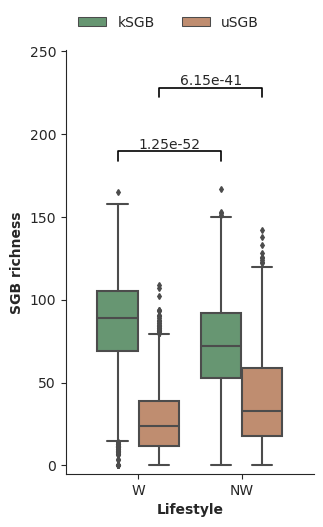

In [22]:
long = richness.melt(id_vars='lifestyle', value_vars=['kSGB', 'uSGB'],
                     var_name='SGB type', value_name='richness')

fig, ax = plt.subplots(figsize=(3.2, 5.5))
sns.boxplot(data=long, x='lifestyle', y='richness', hue='SGB type', ax=ax,
            order=['Westernized', 'Non-Westernized'],
            palette=SGB_TYPE_COLORS, flierprops={'markersize': 3})


def stat_bracket(ax, x1, x2, y, p_value, height):
    ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y], lw=1.2, c='black')
    ax.text((x1 + x2) / 2, y + height, f'{p_value:.2e}', ha='center', va='bottom', fontsize=10)


# Brackets sit above the data: the kSGB comparison first, the uSGB one above it.
top = richness[['kSGB', 'uSGB']].to_numpy().max()
stat_bracket(ax, -0.2, 0.8, top * 1.10, p_values['kSGB'], height=top * 0.035)
stat_bracket(ax, 0.2, 1.2, top * 1.33, p_values['uSGB'], height=top * 0.035)
ax.set_ylim(-0.03 * top, top * 1.50)
ax.set_xticklabels(['W', 'NW'])
ax.set_xlabel('Lifestyle', fontweight='bold')
ax.set_ylabel('SGB richness', fontweight='bold')
ax.legend(title=None, loc='lower left', bbox_to_anchor=(0, 1.02), ncol=2, frameon=False)
sns.despine()
plt.show()

## 3. Figures 2b and 2c — Jaccard PCoA

Both panels show the same ordination, built from presence/absence of SGBs across the adult and ancient samples. The sign of a principal coordinate is arbitrary, so the axes are oriented to put the NW samples to the top right, which keeps the plot stable across runs.

In [23]:
prevalence_matrix = (display_abundances > 0).astype(int).T   # samples x SGBs

jaccard = beta_diversity(metric='jaccard', counts=prevalence_matrix.values,
                         ids=list(prevalence_matrix.index))
ordination = pcoa(jaccard)

variance = 100 * ordination.eigvals / ordination.eigvals.sum()
coords = ordination.samples[['PC1', 'PC2']].copy()
coords.index = prevalence_matrix.index
coords['lifestyle'] = display_meta.loc[coords.index, 'lifestyle']
coords['HDI'] = display_meta.loc[coords.index, 'HDI']

# Orient both axes so that the non-Westernized samples sit top right.
centroids = coords.groupby('lifestyle')[['PC1', 'PC2']].mean()
for axis in ('PC1', 'PC2'):
    if centroids.loc['Non-Westernized', axis] < centroids.loc['Westernized', axis]:
        coords[axis] = -coords[axis]

print(f'PCoA1 {variance["PC1"]:.2f}%   PCoA2 {variance["PC2"]:.2f}%')
coords.head()

PCoA1 8.59%   PCoA2 6.31%


,PC1,PC2,lifestyle,HDI
O2_UC49_0,-0.169931,-0.026556,Westernized,0.904
O2_UC49_2,-0.054150,-0.162800,Westernized,0.904
O2_UC50_0,0.054117,-0.195756,Westernized,0.904
O2_UC50_2,-0.067545,-0.188221,Westernized,0.904
O2_UC51_0,0.038281,-0.193071,Westernized,0.904


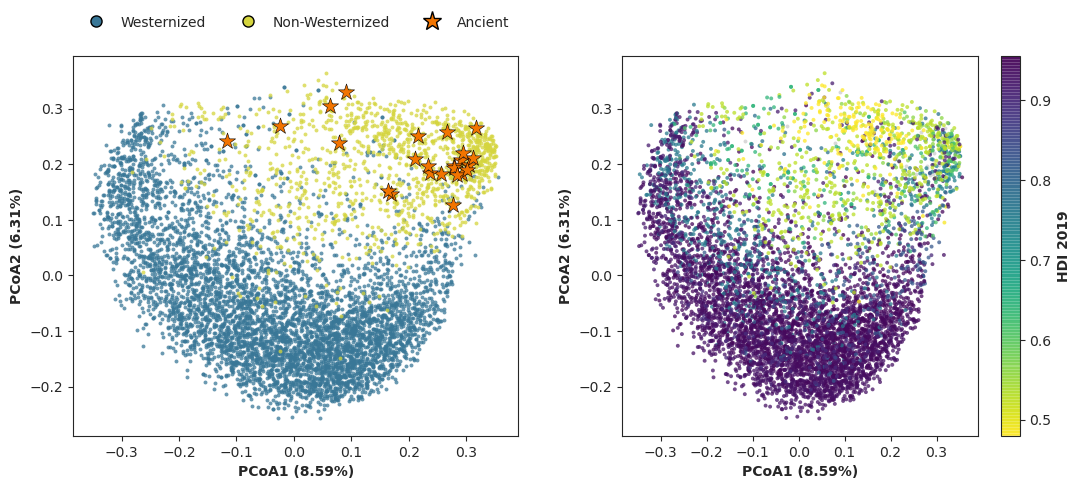

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# lifestyle
ax = axes[0]
for lifestyle in ('Westernized', 'Non-Westernized'):
    subset = coords[coords['lifestyle'] == lifestyle]
    ax.scatter(subset['PC1'], subset['PC2'], s=8, alpha=0.75,
               c=SCATTER_COLORS[lifestyle], linewidths=0)
ancient = coords[coords['lifestyle'] == 'Ancient']
ax.scatter(ancient['PC1'], ancient['PC2'], s=150, marker='*',
           c=SCATTER_COLORS['Ancient'], edgecolors='black', linewidths=0.4)
ax.legend(handles=[
    Line2D([], [], marker='o', linestyle='', markersize=8, label='Westernized',
           markerfacecolor=SCATTER_COLORS['Westernized'], markeredgecolor='black'),
    Line2D([], [], marker='o', linestyle='', markersize=8, label='Non-Westernized',
           markerfacecolor=SCATTER_COLORS['Non-Westernized'], markeredgecolor='black'),
    Line2D([], [], marker='*', linestyle='', markersize=14, label='Ancient',
           markerfacecolor=SCATTER_COLORS['Ancient'], markeredgecolor='black'),
], loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=3, frameon=False)

# HDI
ax = axes[1]
no_hdi = coords[coords['HDI'].isna()]
ax.scatter(no_hdi['PC1'], no_hdi['PC2'], s=8, c='#d9d9d9', linewidths=0)
with_hdi = coords[coords['HDI'].notna()]
points = ax.scatter(with_hdi['PC1'], with_hdi['PC2'], s=8, alpha=0.75,
                    c=with_hdi['HDI'], cmap='viridis_r', linewidths=0)
colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label('HDI 2019', fontweight='bold')

for ax in axes:
    ax.set_xlabel(f'PCoA1 ({variance["PC1"]:.2f}%)', fontweight='bold')
    ax.set_ylabel(f'PCoA2 ({variance["PC2"]:.2f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

PERMANOVA on the same distances, for the effect sizes quoted alongside the panels. Each test runs 999 permutations and takes a few minutes.

In [21]:
def permanova_r2(distances, grouping, permutations=999):
    result = skbio.stats.distance.permanova(distances, grouping, permutations=permutations)
    f, n, k = result['test statistic'], result['sample size'], result['number of groups']
    return pd.Series({'pseudo-F': f, 'p-value': result['p-value'],
                      'R2': 1 - 1 / (1 + f * k / (n - k - 1))})


modern = coords.index[coords['lifestyle'] != 'Ancient']
jaccard_modern = jaccard.filter(list(modern))

pd.DataFrame({
    'lifestyle': permanova_r2(jaccard_modern, display_meta.loc[modern, 'lifestyle']),
    'HDI': permanova_r2(jaccard_modern, display_meta.loc[modern, 'HDI']),
})

,lifestyle,HDI
pseudo-F,357.020808,42.723061
p-value,0.001000,0.001000
R2,0.094300,0.153528


## 4. Differential prevalence between lifestyles

The presence/absence of each taxon is modelled with a Bayesian binomial mixed model, with lifestyle, age and gender as fixed effects and study as a random effect. Taxa present in under 10% of both groups, or in over 90% of both, are skipped. P-values come from the posterior mean and SD of the lifestyle coefficient and are FDR-corrected.

This is the expensive step: around a thousand models per taxonomic level, hours in total. Results are cached per level, so the fitting runs once.

In [ ]:
def match_key(name):
    """Key used to match cached model results to taxa, whatever punctuation the names carry."""
    return name.replace('_', '').replace(' ', '').replace('(', '').replace(')', '')


def load_cached_models(path, taxa):
    """Read cached model results and re-label them with the taxon names used here."""
    models = pd.read_table(path, index_col=0)
    keys = {match_key(x): x for x in taxa}
    if len(keys) != len(taxa):
        raise ValueError('taxon names are not unique after normalisation')
    renamed = [keys.get(match_key(x)) for x in models.index]
    unmatched = [x for x, new in zip(models.index, renamed) if new is None]
    if unmatched:
        print(f'{len(unmatched)} cached results match no current taxon, e.g. {unmatched[:3]}')
    models.index = renamed
    return models[models.index.notna()]


def fit_prevalence_models(abundances, meta, level, cache=CACHE_MODELS, verbose=False):
    """Bayesian binomial mixed model of presence/absence against lifestyle, per taxon."""
    path = cache.format(level=level)
    if os.path.exists(path):
        return load_cached_models(path, abundances.index)

    covariates = meta[['study_name', 'age', 'gender', 'non_westernized']].copy()
    covariates['age'] = covariates['age'].astype(float)
    low, high = PREVALENCE_FILTER
    is_w = covariates['non_westernized'] == 'no'
    results = {}
    for taxon in abundances.index:
        name = 'taxon'
        table = covariates.copy()
        table[name] = (abundances.loc[taxon, covariates.index] > 0).astype(int)
        w_prev, nw_prev = table.loc[is_w, name].mean(), table.loc[~is_w, name].mean()
        if max(w_prev, nw_prev) < low or min(w_prev, nw_prev) >= high:
            continue
        model = BinomialBayesMixedGLM.from_formula(
            f'{name} ~ non_westernized + age + C(gender)',
            {'study': '0 + C(study_name)'}, table, vcp_p=.5)
        fitted = model.fit_map().summary().tables[0]
        z = (fitted['Post. Mean']['non_westernized[T.yes]']
             / fitted['Post. SD']['non_westernized[T.yes]'])
        results[taxon] = [z, 2 * sts.norm.cdf(-abs(z))]
        if verbose:
            print(f'{taxon} z={z:.2f}')

    models = pd.DataFrame.from_dict(results, orient='index', columns=['z-score', 'p-value'])
    models['q-value'] = fdrcorrection(models['p-value'])[1]
    models.to_csv(path, sep='\t')
    return models


sgb_models = fit_prevalence_models(model_abundances, model_meta, 'sgb')
significant = sgb_models[sgb_models['q-value'] < Q_THRESHOLD]
print(f'{len(sgb_models):,} SGBs modelled, {len(significant):,} significant at q < {Q_THRESHOLD}')
significant.sort_values('z-score').head()

Significance alone does not order the taxa for the figure. The ranking uses the prevalence difference: prevalence is computed per study, averaged over the Westernized studies and over the non-Westernized studies, and the two averages subtracted. Averaging by study rather than pooling samples keeps the large Westernized cohorts from dominating.

In [ ]:
def prevalence_by_study(abundances, meta):
    """Prevalence (%) of each taxon within each (study, lifestyle) group."""
    present = (abundances.loc[:, meta.index] > 0).astype(int).T
    present = present.join(meta[['study_name', 'lifestyle']])
    return present.groupby(['study_name', 'lifestyle']).mean() * 100


def prevalence_difference(abundances, meta):
    """Mean Westernized prevalence minus mean non-Westernized prevalence, averaged over studies."""
    per_study = prevalence_by_study(abundances, meta)
    w = per_study.xs('Westernized', level='lifestyle').mean()
    nw = per_study.xs('Non-Westernized', level='lifestyle').mean()
    return (w - nw).sort_values()


def top_discriminative(difference, models, n=N_TOP):
    """The n most non-Westernized- and n most Westernized-enriched taxa, in that order."""
    significant = models.index[models['q-value'] < Q_THRESHOLD]
    ranked = difference[difference.index.isin(significant)]
    if len(ranked) < 2 * n:
        print(f'only {len(ranked)} significant taxa: the two sides of the heatmap overlap')
    # dict.fromkeys keeps the order and drops any taxon picked from both ends.
    return list(dict.fromkeys(list(ranked.index[:n]) + list(ranked.index[::-1][:n])))


sgb_difference = prevalence_difference(model_abundances, model_meta)
selected_sgbs = top_discriminative(sgb_difference, sgb_models)
sgb_difference.loc[selected_sgbs].rename('prevalence difference (W - NW)').to_frame()

## 5. Figure 2d — SGB prevalence heatmap

Columns are studies, ordered Westernized, non-Westernized, ancient before clustering; values are the prevalence of each SGB within each study. Ancient samples appear here even though they take no part in the model, since they have no age or gender.

In [ ]:
def prevalence_heatmap(abundances, meta, taxa, row_types=True, figsize=(15, 10), labeller=None):
    if len(taxa) < 2:
        raise ValueError(f'{len(taxa)} taxa selected: nothing to cluster. '
                         'Check the q-value threshold and the prevalence filter.')
    per_study = prevalence_by_study(abundances.loc[taxa], meta)
    data = per_study.T
    order = [c for lifestyle in LIFESTYLE_ORDER for c in data.columns if c[1] == lifestyle]
    data = data[order]

    col_colors = pd.Series([LIFESTYLE_COLORS[lifestyle] for _, lifestyle in data.columns],
                           index=[study for study, _ in data.columns], name='Lifestyle')
    data.columns = [study for study, _ in data.columns]
    row_colors = None
    if row_types:
        row_colors = pd.Series(
            [SGB_TYPE_COLORS['uSGB' if is_usgb(x) else 'kSGB'] for x in data.index],
            index=data.index, name='SGB type')
    if labeller is not None:
        data.index = [labeller(x) for x in data.index]
        if row_colors is not None:
            row_colors.index = data.index

    with sns.plotting_context('notebook', font_scale=0.75):
        grid = sns.clustermap(data, cmap='coolwarm', vmin=0, vmax=100, figsize=figsize,
                              col_colors=col_colors, row_colors=row_colors,
                              cbar_kws={'label': 'Prevalence (%)', 'orientation': 'horizontal'},
                              dendrogram_ratio=(0.08, 0.12))
    grid.ax_heatmap.set_xlabel('')
    grid.ax_heatmap.set_ylabel('')
    # Colour bar and legend go in the empty corner above the row dendrogram.
    grid.ax_cbar.set_position([0.02, 0.88, 0.09, 0.02])
    handles = [Patch(facecolor=LIFESTYLE_COLORS[l], label=l) for l in LIFESTYLE_ORDER]
    if row_types:
        handles += [Patch(facecolor=c, label=t) for t, c in SGB_TYPE_COLORS.items()]
    grid.figure.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.01, 0.82),
                       frameon=False, fontsize=8)
    return grid


prevalence_heatmap(display_abundances, display_meta, selected_sgbs, labeller=display_label)
plt.show()

## 6. Figure S3 — *Prevotella*, *Bacteroides* and *Phocaeicola*

Every SGB of these three genera that is present in more than 10% of the samples, rather than a model-selected subset. Genus matching uses the names as they appear in the profiles, so the *Prevotella* SGBs now split across *Prevotella* and *Segatella* are all captured; the labels show the updated names.

In [ ]:
GENERA_S3 = ('Prevotella', 'Bacteroides', 'Phocaeicola')
MIN_PREVALENCE_S3 = 0.1

in_genera = [x for x in display_abundances.index if x.split(' ')[0] in GENERA_S3]
prevalence = (display_abundances.loc[in_genera] > 0).mean(axis=1)
selected_s3 = list(prevalence[prevalence > MIN_PREVALENCE_S3].index)

print(f'{len(selected_s3)} SGBs of {GENERA_S3} above {MIN_PREVALENCE_S3:.0%} prevalence')
prevalence_heatmap(display_abundances, display_meta, selected_s3,
                   figsize=(15, 9), labeller=display_label)
plt.show()

## 7. Figure S4 — genus and family level

The same pipeline as panel d, applied to genus- and family-level profiles. Each level gets its own models, its own prevalence differences and its own top 15 per side.

In [ ]:
def read_rank_profiles(path, rank, child_rank):
    """Read a merged MetaPhlAn table and keep the rows that stop at the given rank."""
    table = pd.read_table(path, index_col=0)
    table = table.loc[[(f'{rank}__' in x and f'{child_rank}__' not in x) for x in table.index]]
    table.index = [x.split('|')[-1][3:] for x in table.index]
    return table.groupby(level=0).sum()   # same name under different lineages


def heatmap_for_rank(rank, child_rank, level, figsize=(15, 9)):
    abundances = read_rank_profiles(PROFILES, rank, child_rank)
    display_table = drop_empty(abundances[display_meta.index])
    model_table = drop_empty(abundances[model_meta.index])

    models = fit_prevalence_models(model_table, model_meta, level)
    difference = prevalence_difference(model_table, model_meta)
    selected = top_discriminative(difference, models)
    print(f'{level}: {len(models):,} modelled, '
          f'{(models["q-value"] < Q_THRESHOLD).sum():,} significant at q < {Q_THRESHOLD}')
    grid = prevalence_heatmap(display_table, display_meta, selected,
                              row_types=False, figsize=figsize)
    return grid, models, difference


# --- S4a: genus level ---
genus_grid, genus_models, genus_difference = heatmap_for_rank('g', 's', 'genus')
plt.show()

In [ ]:
# --- S4b: family level ---
family_grid, family_models, family_difference = heatmap_for_rank('f', 'g', 'family')
plt.show()

## 8. Figure S2 — sensitivity to per-study bias

Section 4 found SGBs whose presence differs between lifestyles, with study as a random effect. The
worry that remains is confounding by study: a handful of cohorts with different sample handling,
DNA extraction or sequencing depth could manufacture the signal on their own. This section asks how
much deliberate, adversarial distortion the result survives.

Each replicate draws a random subset of studies, flips a fraction of their presence/absence calls
in a randomly chosen direction, and re-fits the model. Two regimes are run:

* **25/20** — a quarter of the studies biased, 20% of their calls flipped
* **50/20** — half of the studies biased, 20% of their calls flipped

Within one replicate the direction is drawn per study *and* per SGB, so a study can lose presences
for one SGB and gain them for another. That is harsher than a uniformly over- or under-sensitive
study, which is the point: it is a worst case, not a model of any particular artefact.

Per-replicate estimates are pooled with Rubin's rules, which keeps both the uncertainty of each fit
and the spread across replicates: the pooled effect is the mean of the per-replicate effects, and
the total variance is the mean within-replicate variance plus `(1 + 1/R)` times the between-
replicate variance.

The panel shows the baseline effect beside the two pooled effects, and the share of replicates in
which each SGB stayed significant.

### 8.1 Settings

One replicate is one model fit per SGB, so
the full modelled set at 100 replicates across two regimes is hundreds of thousands of fits.
Restricting it to the SGBs with the strongest baseline effects — the ones the panel shows — keeps
this to something that finishes, at the cost that the FDR correction in section 8.5 is then taken
over that reduced set rather than over all modelled SGBs. Set `SENSITIVITY_TAXA` to
`list(sgb_models.index)` for the full analysis, and start with `N_REPLICATES = 10` while testing.

In [ ]:
N_REPLICATES = 100
BIAS_MAGNITUDE = 0.20                     # fraction of calls flipped inside a biased study
REGIMES = {'25/20': 0.25, '50/20': 0.50}  # label -> fraction of studies biased
ALPHA = 0.05
N_TOP_S2 = 15                             # SGBs taken from each end of the baseline effect

CACHE_BASELINE = './cache_s2_baseline_effects.tsv'
CACHE_POOLED = './cache_s2_pooled_{regime}.tsv'
CACHE_REPLICATE_P = './cache_s2_replicate_pvalues_{regime}.tsv'

REGIME_COLORS = {'Baseline': '#AED6F1', '25/20': '#F9E79F', '50/20': '#F5B7B1'}

# The SGBs to put through the sensitivity analysis: the strongest baseline effects in each
# direction, with a margin so that the final 15 + 15 of the panel come from a real candidate pool.
candidate_sgbs = sgb_models[sgb_models['q-value'] < Q_THRESHOLD].sort_values('z-score')
SENSITIVITY_TAXA = (list(candidate_sgbs.index[:2 * N_TOP_S2])
                    + list(candidate_sgbs.index[-2 * N_TOP_S2:]))

print(f'{len(SENSITIVITY_TAXA)} SGBs x {N_REPLICATES} replicates x {len(REGIMES)} regimes = '
      f'{len(SENSITIVITY_TAXA) * N_REPLICATES * len(REGIMES):,} model fits')

### 8.2 One fit

The model is the one from section 4, pulled out into two small functions so that the baseline and
the biased replicates fit exactly the same specification. `lifestyle_table` returns one row per
sample with the covariates and a binary `presence` column; `fit_lifestyle_effect` returns the
posterior mean and SD of the lifestyle coefficient.

In [ ]:
def lifestyle_table(abundances, meta, taxon):
    """Covariates plus the binary presence of one taxon, one row per sample."""
    table = meta[['study_name', 'age', 'gender', 'non_westernized']].copy()
    table['age'] = table['age'].astype(float)
    table['presence'] = (abundances.loc[taxon, table.index] > 0).astype(int)
    return table


def fit_lifestyle_effect(table):
    """Posterior mean and SD of the non-Westernized coefficient."""
    model = BinomialBayesMixedGLM.from_formula(
        'presence ~ non_westernized + age + C(gender)',
        {'study': '0 + C(study_name)'}, table, vcp_p=.5)
    fitted = model.fit_map().summary().tables[0]
    return (fitted['Post. Mean']['non_westernized[T.yes]'],
            fitted['Post. SD']['non_westernized[T.yes]'])

### 8.3 Baseline effects

Section 4 cached only the z-score, and the panel needs the posterior mean and SD to draw the error
bars, so the unbiased model is re-fitted once per SGB here. This is the cheap part: one fit each.

In [ ]:
def baseline_effects(abundances, meta, taxa, cache=CACHE_BASELINE):
    if os.path.exists(cache):
        cached = pd.read_table(cache, index_col=0)
        if set(taxa).issubset(cached.index):
            return cached.loc[taxa]

    rows = {taxon: fit_lifestyle_effect(lifestyle_table(abundances, meta, taxon))
            for taxon in taxa}
    effects = pd.DataFrame.from_dict(rows, orient='index', columns=['mean_base', 'std_base'])
    effects['z_base'] = effects['mean_base'] / effects['std_base']
    effects.to_csv(cache, sep='\t')
    return effects


df_res_baseline = baseline_effects(model_abundances, model_meta, SENSITIVITY_TAXA)
df_res_baseline.sort_values('z_base').head()

### 8.4 The replicates

`inject_bias` edits one study at a time: it picks a target state, finds the samples in that study
that are not already in it, and flips `BIAS_MAGNITUDE` of them. A fit that fails costs that one
replicate rather than the whole run, and the pooling reports how many succeeded.

In [ ]:
def inject_bias(table, studies, magnitude, rng):
    """Flip a fraction of the presence calls of each biased study, direction drawn at random."""
    for study in studies:
        target = int(rng.integers(2))        # 1 = invent presences, 0 = erase them
        candidates = table.index[(table['study_name'] == study) & (table['presence'] != target)]
        n_to_flip = int(len(candidates) * magnitude)
        if n_to_flip:
            table.loc[rng.choice(candidates, size=n_to_flip, replace=False), 'presence'] = target
    return table


def run_sensitivity_replicates(abundances, meta, taxa, pct_studies_to_bias,
                               bias_magnitude=BIAS_MAGNITUDE, n_replicates=N_REPLICATES,
                               seed=SEED):
    """Re-fit the lifestyle model under injected per-study bias, n_replicates times."""
    rng = np.random.default_rng(seed)
    covariates = meta[['study_name', 'age', 'gender', 'non_westernized']].copy()
    covariates['age'] = covariates['age'].astype(float)
    presence = (abundances.loc[taxa, covariates.index] > 0).astype(int).T   # samples x taxa

    studies = covariates['study_name'].unique()
    n_biased = int(len(studies) * pct_studies_to_bias)
    draws = {taxon: {'means': [], 'sds': []} for taxon in taxa}

    for replicate in range(n_replicates):
        print(f'  replicate {replicate + 1}/{n_replicates}', end='\r')
        biased_studies = rng.choice(studies, size=n_biased, replace=False)
        for taxon in taxa:
            table = inject_bias(covariates.assign(presence=presence[taxon]),
                                biased_studies, bias_magnitude, rng)
            try:
                mean, sd = fit_lifestyle_effect(table)
            except Exception as error:
                print(f'\n  replicate {replicate + 1} failed for {taxon}: {error}')
                continue
            draws[taxon]['means'].append(mean)
            draws[taxon]['sds'].append(sd)
    print()
    return draws


def pool_replicates(means, sds):
    """Rubin's rules: pooled effect, total variance, pooled test, per-replicate p-values."""
    means, sds = np.asarray(means), np.asarray(sds)
    n = len(means)
    if n < 2:
        return None

    pooled_mean = np.mean(means)
    within = np.mean(sds ** 2)                       # average sampling variance
    between = np.var(means, ddof=1)                  # spread across replicates
    pooled_sd = np.sqrt(within + (1 + 1 / n) * between)
    pooled_z = pooled_mean / pooled_sd
    return {
        'pooled_mean': pooled_mean,
        'pooled_sd': pooled_sd,
        'pooled_z': pooled_z,
        'pooled_p': 2 * sts.norm.cdf(-abs(pooled_z)),
        'n_replicates': n,
        'replicate_p': 2 * sts.norm.cdf(-np.abs(means / sds)),
    }

### 8.5 Running both regimes

Two tables come out of each regime: the pooled effect per SGB, and the per-replicate p-values, kept
because the bar panel of the figure needs them. `pooled_q` corrects the pooled p-value across SGBs;
`pct_replicates_significant` is the share of replicates in which an SGB survived FDR correction
applied **across SGBs within that replicate**, which is stricter than counting raw p-values.

Both tables are cached per regime, since this is the hours-long cell.

In [ ]:
def run_regime(label, pct_studies_to_bias):
    pooled_path = CACHE_POOLED.format(regime=label.replace('/', '_'))
    replicate_path = CACHE_REPLICATE_P.format(regime=label.replace('/', '_'))
    if os.path.exists(pooled_path) and os.path.exists(replicate_path):
        return (pd.read_table(pooled_path, index_col=0),
                pd.read_table(replicate_path, index_col=0))

    print(f'=== regime {label}: {pct_studies_to_bias:.0%} of studies biased by '
          f'{BIAS_MAGNITUDE:.0%} ===')
    draws = run_sensitivity_replicates(model_abundances, model_meta, SENSITIVITY_TAXA,
                                       pct_studies_to_bias)

    pooled, replicate_p = {}, {}
    for taxon, values in draws.items():
        result = pool_replicates(values['means'], values['sds'])
        if result is None:
            print(f'  {taxon}: too few successful replicates, dropped')
            continue
        replicate_p[taxon] = result.pop('replicate_p')
        pooled[taxon] = result

    pooled = pd.DataFrame(pooled).T
    pooled['pooled_q'] = fdrcorrection(pooled['pooled_p'])[1]

    # FDR across SGBs within each replicate, then the share of replicates that stayed significant.
    replicate_p = pd.DataFrame(replicate_p).T
    replicate_q = replicate_p.apply(lambda column: fdrcorrection(column)[1], axis=0)
    pooled['pct_replicates_significant'] = (replicate_q < ALPHA).mean(axis=1) * 100

    pooled.to_csv(pooled_path, sep='\t')
    replicate_p.to_csv(replicate_path, sep='\t')
    return pooled, replicate_p


sensitivity = {label: run_regime(label, pct)[0] for label, pct in REGIMES.items()}
sensitivity['25/20'].head()

### 8.6 The SGBs to show

The 15 SGBs most strongly associated with each lifestyle in the **baseline** model, sorted by
baseline effect so the panel runs from Westernized-enriched at the bottom to non-Westernized
enriched at the top.

In [ ]:
df_merged = df_res_baseline.copy()
for label, table in sensitivity.items():
    df_merged = df_merged.join(table.add_suffix('_' + label.replace('/', '_')), how='inner')

by_z = df_merged.sort_values('z_base')
top30_species = pd.concat([by_z.head(N_TOP_S2),     # Westernized enriched
                           by_z.tail(N_TOP_S2)])    # non-Westernized enriched
top30_species = top30_species.sort_values('mean_base')

top30_species[['mean_base', 'pooled_mean_25_20', 'pooled_mean_50_20',
               'pct_replicates_significant_25_20', 'pct_replicates_significant_50_20']]

### 8.7 Plotting

Left: the baseline effect and the two pooled effects, each a diamond with its SD, on three rows per
SGB so they do not overlap. Right: the share of replicates in which the SGB stayed significant
under each regime; the baseline has no bar, since it has no replicates.

In [ ]:
SERIES = [('Baseline', 'mean_base', 'std_base'),
          ('25/20', 'pooled_mean_25_20', 'pooled_sd_25_20'),
          ('50/20', 'pooled_mean_50_20', 'pooled_sd_50_20')]

y_pos = np.arange(len(top30_species))
offsets = {'Baseline': 0.25, '25/20': 0.0, '50/20': -0.25}
bar_height = 0.4

fig, (ax_plot, ax_p) = plt.subplots(1, 2, figsize=(8, 9), sharey=True,
                                    gridspec_kw={'width_ratios': [6, 1], 'wspace': 0.05})

for label, mean_column, sd_column in SERIES:
    ax_plot.errorbar(x=top30_species[mean_column], y=y_pos + offsets[label],
                     xerr=top30_species[sd_column], fmt='d', markersize=8, linestyle='',
                     c=REGIME_COLORS[label], mec='k', mew=1, ecolor='k', capsize=2, label=label)

ax_plot.axvline(0, ls='--', color='gray')
ax_plot.set_yticks(y_pos)
ax_plot.set_yticklabels([display_label(x) for x in top30_species.index])
ax_plot.set_ylim(-0.7, len(top30_species) - 0.3)
ax_plot.set_xlabel('log(odds-ratio)', fontweight='bold')
ax_plot.legend(loc='upper left', frameon=False)

for label in REGIMES:
    column = 'pct_replicates_significant_' + label.replace('/', '_')
    ax_p.barh(y=y_pos + offsets[label], width=top30_species[column], height=bar_height,
              color=REGIME_COLORS[label], edgecolor='k', linewidth=0.8)

ax_p.set_xlabel('% replicates sign.', fontweight='bold')
ax_p.set_xlim(0, 101)
ax_p.set_xticks([0, 100])
ax_p.grid(axis='x', linestyle=':', alpha=0.6)
sns.despine(ax=ax_plot)
sns.despine(ax=ax_p, left=True)
plt.show()

## 9. Figure S1 — diversity, MAG yield and sequencing depth

| Panel | Content |
| --- | --- |
| **a, b, c** | SGB richness, Shannon and Simpson diversity, Westernized vs non-Westernized |
| **d** | SGB richness against the number of MAGs reconstructed from the same sample |
| **e** | Sequencing depth, Westernized vs non-Westernized |
| **f** | Bray-Curtis PCoA of SGB relative abundances |
| **g** | Jaccard PCoA of SGB presence/absence |
| **h** | Distance to the lifestyle centroid in the Jaccard ordination (beta dispersion) |

### 9.1 Alpha diversity on the complete profiles


In [13]:
BETA_METRIC = 'braycurtis'        # panel f
DISPERSION_FROM = 'jaccard'       # panel h: 'jaccard' (panel g) or 'braycurtis' (panel f)
S1_COLORS = {'Westernized': SCATTER_COLORS['Westernized'],
             'Non-Westernized': SCATTER_COLORS['Non-Westernized']}
S1_ORDER = ['Westernized', 'Non-Westernized']

# Every S1 panel uses the modern samples of the display set: adults, no ancient.
s1_meta = display_meta[display_meta['lifestyle'] != 'Ancient']
s1_abundances = display_abundances[s1_meta.index]


def alpha_diversity(abundances):
    """Richness, Shannon (log2) and Simpson per sample, from a taxa x samples table."""
    proportions = abundances / abundances.sum()
    nonzero = proportions.where(proportions > 0)
    return pd.DataFrame({
        'SGB richness': (abundances > 0).sum(),
        'Shannon': -(nonzero * np.log2(nonzero)).sum(),
        'Simpson': 1 - (proportions ** 2).sum(),
    })


diversity = alpha_diversity(s1_abundances)
diversity['Number of reads'] = s1_meta['number_reads'].astype(float)
diversity['lifestyle'] = s1_meta['lifestyle']

S1_METRICS = ['SGB richness', 'Shannon', 'Simpson', 'Number of reads']


def lifestyle_mannwhitney(frame, column):
    groups = frame.groupby('lifestyle')[column]
    return sts.mannwhitneyu(groups.get_group('Westernized'),
                            groups.get_group('Non-Westernized'),
                            alternative='two-sided').pvalue


s1_pvalues = {metric: lifestyle_mannwhitney(diversity, metric) for metric in S1_METRICS}

summary = diversity.groupby('lifestyle')[S1_METRICS].median().loc[S1_ORDER]
summary.loc['Mann-Whitney p'] = pd.Series(s1_pvalues)
summary

,SGB richness,Shannon,Simpson,Number of reads
lifestyle,,,,
Westernized,2.480000e+02,5.622280e+00,9.578471e-01,3.446483e+07
Non-Westernized,2.930000e+02,5.346818e+00,9.459698e-01,4.403466e+07
Mann-Whitney p,1.631615e-39,1.942254e-12,1.585751e-22,2.335100e-07


### 9.2 Panel d — richness against MAG yield

The MAG counts come from the same SGB release file that section 1 reads for the taxonomy. Each
reconstructed genome is named `study__sample__bin.N`, so counting the genome ids per sample gives
the number of MAGs assembled from it. Reference genomes are not counted.

Samples are matched on the sample id alone rather than on `study__sample`. The study names in the
release file do not always match the metadata (`ThomasAM_2019_a` against `ThomasAM_2019`, and so
on), and matching on the study would need a hand-written rename table to avoid dropping those
cohorts silently.

Deeper sequencing yields both more SGBs and more MAGs, so the raw correlation is partly a depth
effect. The model below estimates the MAG-count relationship with log depth held constant, and the
panel plots richness adjusted for depth, which is what makes the two lifestyle lines comparable.

In [14]:
import statsmodels.formula.api as smf
from collections import Counter


def read_mag_counts(path):
    """Number of MAGs reconstructed per sample, from the SGB release file."""
    counts = Counter()
    with bz2.open(path, 'rt') as handle:
        for line in handle:
            if line.startswith('GGB'):
                break
            if not line.startswith('SGB'):
                continue
            genomes = line.strip().split('\t')[4]        # reconstructed genomes, not references
            for genome in genomes.split(','):
                parts = genome.split('__')
                if len(parts) > 2:                       # study__sample__bin.N
                    counts[parts[1]] += 1
    return pd.Series(counts, name='mag_count')


mag_counts = read_mag_counts(SGB_DB)

mag_model_data = diversity.join(mag_counts, how='inner')     # samples with at least one MAG
mag_model_data['non_westernized'] = s1_meta.loc[mag_model_data.index, 'non_westernized']
mag_model_data = mag_model_data.dropna(subset=['SGB richness', 'Number of reads'])
mag_model_data['richness'] = mag_model_data['SGB richness']
mag_model_data['log10_reads'] = np.log10(mag_model_data['Number of reads'])

mag_model = smf.ols('mag_count ~ richness * C(non_westernized) + log10_reads',
                    data=mag_model_data).fit()

# Richness with the sequencing-depth term removed, centred on the mean depth.
depth_coefficient = mag_model.params['log10_reads']
mag_model_data['adjusted_richness'] = (
    mag_model_data['richness']
    - depth_coefficient * (mag_model_data['log10_reads'] - mag_model_data['log10_reads'].mean()))

print(f'{len(mag_model_data):,} samples with MAGs, '
      f'{mag_model_data["mag_count"].sum():,} MAGs in total')
print(mag_model.summary().tables[1])

3,704 samples with MAGs, 83,881 MAGs in total
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                           -163.2658      3.588    -45.507      0.000    -170.300    -156.232
C(non_westernized)[T.yes]              9.7052      0.868     11.180      0.000       8.003      11.407
richness                               0.0733      0.002     39.186      0.000       0.070       0.077
richness:C(non_westernized)[T.yes]    -0.0452      0.003    -15.975      0.000      -0.051      -0.040
log10_reads                           21.9653      0.487     45.066      0.000      21.010      22.921


### 9.3 Panels f, g and h — beta diversity

Panel g reuses the Jaccard distances from section 3, restricted to the modern samples. Panel f adds
an abundance-based ordination of the same samples. Panel h is the beta dispersion: the distance from
each sample to the centroid of its lifestyle, measured across every principal coordinate with a
positive eigenvalue (equivalent to PERMDIST)

Both ordinations have an arbitrary axis sign, so they are oriented to put the NW
samples to the right, as in Figure 2b.

In [24]:
def orient_right(coords, lifestyles, axes=('PC1', 'PC2')):
    """Flip axes so the non-Westernized centroid sits to the top right. Signs are arbitrary."""
    centroids = coords.groupby(lifestyles)[list(axes)].mean()
    for axis in axes:
        if centroids.loc['Non-Westernized', axis] < centroids.loc['Westernized', axis]:
            coords[axis] = -coords[axis]
    return coords


def distance_to_centroid(ordination, lifestyles):
    """Euclidean distance from each sample to its group centroid, over the positive axes."""
    positive = ordination.eigvals[ordination.eigvals > 0].index
    space = ordination.samples[positive]
    space.index = lifestyles.index
    centroids = space.groupby(lifestyles).transform('mean')
    return np.sqrt(((space - centroids) ** 2).sum(axis=1))


# Panel g: the section 3 Jaccard distances, modern samples only.
jaccard_s1 = jaccard.filter(list(s1_meta.index))
jaccard_ordination = pcoa(jaccard_s1)
jaccard_coords = jaccard_ordination.samples[['PC1', 'PC2']].set_axis(jaccard_s1.ids)
jaccard_coords = orient_right(jaccard_coords, s1_meta.loc[jaccard_coords.index, 'lifestyle'])

# Panel f: an abundance-based ordination of the same samples.
beta = beta_diversity(metric=BETA_METRIC, counts=s1_abundances.T.values,
                      ids=list(s1_abundances.columns))
beta_ordination = pcoa(beta)
beta_coords = beta_ordination.samples[['PC1', 'PC2']].set_axis(beta.ids)
beta_coords = orient_right(beta_coords, s1_meta.loc[beta_coords.index, 'lifestyle'])

# Panel h: dispersion around the lifestyle centroids.
dispersion_ordination = (jaccard_ordination if DISPERSION_FROM == 'jaccard' else beta_ordination)
dispersion_ids = (jaccard_s1.ids if DISPERSION_FROM == 'jaccard' else beta.ids)
dispersion = pd.DataFrame({
    'Distance to centroid': distance_to_centroid(
        dispersion_ordination, s1_meta.loc[list(dispersion_ids), 'lifestyle']).values,
    'lifestyle': s1_meta.loc[list(dispersion_ids), 'lifestyle'].values,
}, index=list(dispersion_ids))

s1_pvalues['Distance to centroid'] = lifestyle_mannwhitney(dispersion, 'Distance to centroid')

beta_variance = 100 * beta_ordination.eigvals / beta_ordination.eigvals.sum()
jaccard_variance = 100 * jaccard_ordination.eigvals / jaccard_ordination.eigvals.sum()
print(f'{BETA_METRIC}: PCoA1 {beta_variance["PC1"]:.2f}%, PCoA2 {beta_variance["PC2"]:.2f}%')
print(f'jaccard:     PCoA1 {jaccard_variance["PC1"]:.2f}%, PCoA2 {jaccard_variance["PC2"]:.2f}%')
dispersion.groupby('lifestyle')['Distance to centroid'].median()

braycurtis: PCoA1 6.73%, PCoA2 6.45%
jaccard:     PCoA1 8.58%, PCoA2 6.29%


lifestyle
Non-Westernized    0.548409
Westernized        0.543001
Name: Distance to centroid, dtype: float64

### 9.4 Plotting

In [27]:
def box_panel(ax, frame, column, ylabel, p_value=None):
    sns.boxplot(data=frame, x='lifestyle', y=column, order=S1_ORDER, hue='lifestyle',
                hue_order=S1_ORDER, palette=S1_COLORS, linewidth=1.2,
                flierprops={'marker': 'd', 'markersize': 3, 'markerfacecolor': '#3f3f3f',
                            'markeredgecolor': 'none'}, ax=ax)
    if p_value is not None:
        ax.set_title(f'p={p_value:.2e}', fontsize=10, pad=6)
    ax.set_xlabel('Lifestyle', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_xticks(range(len(S1_ORDER)))
    ax.set_xticklabels(['W', 'NW'])


def scatter_panel(ax, coords, variance):
    for lifestyle in S1_ORDER:
        subset = coords[s1_meta.loc[coords.index, 'lifestyle'] == lifestyle]
        ax.scatter(subset['PC1'], subset['PC2'], s=6, alpha=0.8, linewidths=0,
                   c=S1_COLORS[lifestyle], rasterized=True)
    ax.set_xlabel('PCoA1', fontweight='bold')
    ax.set_ylabel('PCoA2', fontweight='bold')


layout = [['a', 'b', 'c', 'd', 'd', 'd'],
          ['e', 'f', 'f', 'g', 'g', 'h']]
fig, axes = plt.subplot_mosaic(layout, figsize=(19, 11))

box_panel(axes['a'], diversity, 'SGB richness', 'SGB richness', s1_pvalues['SGB richness'])
box_panel(axes['b'], diversity, 'Shannon', 'Shannon', s1_pvalues['Shannon'])
box_panel(axes['c'], diversity, 'Simpson', 'Simpson', s1_pvalues['Simpson'])
box_panel(axes['e'], diversity, 'Number of reads', 'Number of reads',
          s1_pvalues['Number of reads'])
box_panel(axes['h'], dispersion, 'Distance to centroid', 'Distance to centroid')

# d: depth-adjusted richness against MAG count, one regression per lifestyle
for lifestyle in S1_ORDER:
    subset = mag_model_data[mag_model_data['lifestyle'] == lifestyle]
    sns.regplot(data=subset, x='mag_count', y='adjusted_richness', ax=axes['d'],
                color=S1_COLORS[lifestyle], ci=95,
                scatter_kws={'s': 10, 'alpha': 0.6, 'edgecolor': 'black', 'linewidths': 0.25,
                             'rasterized': True},
                line_kws={'linewidth': 2})
axes['d'].set_xlabel('MAG count', fontweight='bold')
axes['d'].set_ylabel('SGB richness', fontweight='bold')

scatter_panel(axes['f'], beta_coords, beta_variance)
scatter_panel(axes['g'], jaccard_coords, jaccard_variance)

for letter, ax in axes.items():
    ax.text(-0.12, 1.06, letter, transform=ax.transAxes, fontsize=20, fontweight='bold',
            va='bottom', ha='right')
    for side in ('top', 'right'):
        ax.spines[side].set_visible(True)

fig.legend(handles=[Line2D([], [], marker='o', linestyle='', markersize=10, label=lifestyle,
                           markerfacecolor=S1_COLORS[lifestyle], markeredgecolor='black')
                    for lifestyle in S1_ORDER],
           loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=13)
plt.tight_layout()
plt.show()